In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import my_linear_regression
import importlib
importlib.reload(my_linear_regression)

from my_linear_regression import LinearRegression
lin = LinearRegression()

In [2]:
df = pd.read_csv('data/student_performance/Student_Performance.csv')

df.head()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours_Studied                     10000 non-null  int64  
 1   Previous_Scores                   10000 non-null  int64  
 2   Extracurricular_Activities        10000 non-null  object 
 3   Sleep_Hours                       10000 non-null  int64  
 4   Sample_Question_Papers_Practiced  10000 non-null  int64  
 5   Performance_Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
df.describe()

,Hours_Studied,Previous_Scores,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [5]:
df['Extracurricular_Activities'] = np.where(df['Extracurricular_Activities'] == 'Yes', 1, 0)

In [6]:
from sklearn.model_selection import train_test_split

target = 'Performance_Index'

X = df.drop(target, axis=1)
y = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((6400, 5), (1600, 5), (2000, 5))

In [7]:
lin.fit(X_train, y_train)

MSE loss at epoch 0 = 60.11487669760445


c:\Users\CAVO\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


MSE loss at epoch 100 = inf


d:\Work\Year 3 (2026)\Machine Learning (2026)\Linear-Regression-from-Scratch\my_linear_regression.py:59: RuntimeWarning: overflow encountered in multiply
  grad_w = 2 * (np.dot((y_pred - y_true).T, X)) / n
d:\Work\Year 3 (2026)\Machine Learning (2026)\Linear-Regression-from-Scratch\my_linear_regression.py:25: RuntimeWarning: invalid value encountered in subtract
  w = w - learning_rate * grad_w


MSE loss at epoch 200 = 0.0
MSE loss at epoch 300 = 0.0
MSE loss at epoch 400 = 0.0
MSE loss at epoch 500 = 0.0
MSE loss at epoch 600 = 0.0
MSE loss at epoch 700 = 0.0
MSE loss at epoch 800 = 0.0
MSE loss at epoch 900 = 0.0
MSE loss at epoch 1000 = 0.0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [9]:
lin.fit(X_train_scaled, y_train)

MSE loss at epoch 0 = 3349.888711867908
MSE loss at epoch 100 = 63.22316170264594
MSE loss at epoch 200 = 5.2497051595822635
MSE loss at epoch 300 = 4.224443426845178
MSE loss at epoch 400 = 4.206259634611985
MSE loss at epoch 500 = 4.20593610097508
MSE loss at epoch 600 = 4.205930323864249
MSE loss at epoch 700 = 4.205930220288174
MSE loss at epoch 800 = 4.205930218422669
MSE loss at epoch 900 = 4.205930218388896
MSE loss at epoch 1000 = 4.205930218388281


In [10]:
w, b = lin.w_, lin.b_

w, b

(array([ 7.38594756, 17.6274895 ,  0.30302117,  0.81436978,  0.55486003]),
 array([55.32937491]))

In [11]:
cols = X.columns

print(f'{target} = ')

for idx in range(len(cols)):
    print(f'{w[idx]} * {cols[idx]} ')

print(f'+ {b[0]}')

Performance_Index = 
7.385947560350724 * Hours_Studied 
17.627489497096825 * Previous_Scores 
0.3030211699607794 * Extracurricular_Activities 
0.8143697756807229 * Sleep_Hours 
0.5548600309331309 * Sample_Question_Papers_Practiced 
+ 55.329374907512786


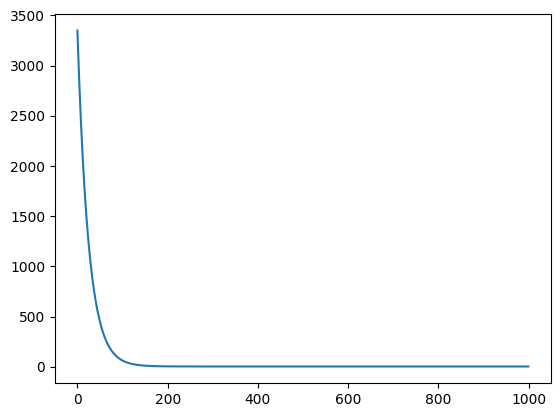

In [12]:
losses = lin.losses_

plt.plot(losses)
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error

y_pred_train = lin.predict(X_train_scaled)
y_pred_val = lin.predict(X_val_scaled)

mean_squared_error(y_train, y_pred_train), mean_squared_error(y_val, y_pred_val)

(4.20593021838828, 4.025776004902991)

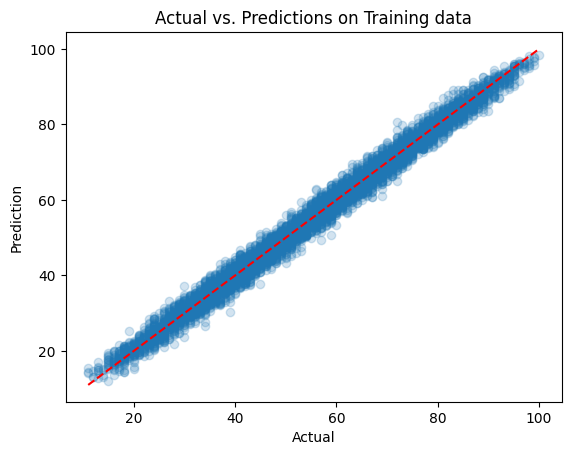

In [14]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [15]:
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

lin.fit(X_train_full_scaled, y_train_full)

MSE loss at epoch 0 = 3348.1769517208363
MSE loss at epoch 100 = 63.14545578255442
MSE loss at epoch 200 = 5.210466809036192
MSE loss at epoch 300 = 4.188113241241807
MSE loss at epoch 400 = 4.170060587125259
MSE loss at epoch 500 = 4.169741592143702
MSE loss at epoch 600 = 4.169735951160141
MSE loss at epoch 700 = 4.169735851325388
MSE loss at epoch 800 = 4.16973584955693
MSE loss at epoch 900 = 4.169735849525574
MSE loss at epoch 1000 = 4.169735849525018


In [16]:
y_pred = lin.predict(X_test_scaled)

mean_squared_error(y_test, y_pred)

4.082628391432156